# Frozen ViViM Backbone: Train a New Custom Classification Head

In [64]:
from pathlib import Path
import os
import random
import subprocess
import textwrap

# Repo paths
ACTION_DIR = Path('/home/swagnik/swagnik/TCSR/video-mamba-suite/video-mamba-suite/action-recognition')
os.chdir(ACTION_DIR)

# GPU selection. You used GPU 1 successfully.
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

# Animals dataset: one subfolder per custom class.
RAW_VIDEO_DIR = Path('/home/swagnik/swagnik/TCSR/Data/Animals')

# Custom classes in the exact label order you want.
# Folder names under RAW_VIDEO_DIR must match these names.
CLASS_NAMES = [
    '1. Dog',
    '2. Cat',
    '3. Fish',
    '4. Bird',
    '5. Cow',
    '6. Mouse',
    '7. Horse',
    '8. Animal',
]

# Where CSVs, outputs, and logs will be written.
DATA_DIR = Path('/home/swagnik/swagnik/TCSR/animals_action_dataset')
OUTPUT_DIR = ACTION_DIR / 'outputs' / 'animals_frozen_head_vivim_tiny'

# Pretrained Kinetics-400 checkpoint from Video Mamba Suite model zoo.
CHECKPOINT = ACTION_DIR / 'checkpoints' / 'deit_vivim_tiny_k400_f16.pt'
CHECKPOINT_URL = 'https://huggingface.co/cg1177/video-mamba-suite/resolve/main/deit_vivim_tiny_k400_f16.pt'

# Model/training settings
MODEL = 'vivim_tiny'
NUM_CLASSES = len(CLASS_NAMES)
EPOCHS = 20
BATCH_SIZE = 4
LR = 1e-3
NUM_WORKERS = 4
SEED = 42

print('Action directory:', ACTION_DIR)
print('CUDA_VISIBLE_DEVICES:', os.environ.get('CUDA_VISIBLE_DEVICES'))
print('Number of custom classes:', NUM_CLASSES)

Action directory: /home/swagnik/swagnik/TCSR/video-mamba-suite/video-mamba-suite/action-recognition
CUDA_VISIBLE_DEVICES: 1
Number of custom classes: 8


## 1. Check CUDA and Mamba imports

In [65]:
import torch
import causal_conv1d, mamba_ssm

print('Torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
print('Visible CUDA device count:', torch.cuda.device_count())
if torch.cuda.is_available():
    print('Visible GPU 0:', torch.cuda.get_device_name(0))
print('Mamba imports: ok')

Torch: 2.1.2+cu118
CUDA available: True
Visible CUDA device count: 1
Visible GPU 0: NVIDIA RTX 4500 Ada Generation
Mamba imports: ok


## Install video-loader dependencies if missing

In [66]:
import importlib.util
import sys
import subprocess

missing = []
for package in ['decord', 'pandas', 'tensorboardX', 'scipy']:
    if importlib.util.find_spec(package) is None:
        missing.append(package)
try:
    import timm
    if timm.__version__ != '0.6.13':
        missing.append('timm==0.6.13')
except Exception:
    missing.append('timm==0.6.13')

if missing:
    print('Installing:', missing)
    subprocess.run([sys.executable, '-m', 'pip', 'install', *missing], check=True)
else:
    print('decord, pandas, and timm already installed')

decord, pandas, and timm already installed


## 2. Download checkpoint if needed

In [67]:
CHECKPOINT.parent.mkdir(parents=True, exist_ok=True)
if not CHECKPOINT.exists():
    print('Downloading checkpoint:', CHECKPOINT_URL)
    subprocess.run(['wget', '-O', str(CHECKPOINT), CHECKPOINT_URL], check=True)
else:
    print('Checkpoint already exists:', CHECKPOINT)

print('Checkpoint size MB:', round(CHECKPOINT.stat().st_size / 1024 / 1024, 2))

Checkpoint already exists: /home/swagnik/swagnik/TCSR/video-mamba-suite/video-mamba-suite/action-recognition/checkpoints/deit_vivim_tiny_k400_f16.pt
Checkpoint size MB: 26.98


## 3. Build train/val/test CSVs from class folders

In [68]:
VIDEO_EXTS = {'.mp4', '.avi', '.mov', '.mkv', '.webm'}
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15

assert RAW_VIDEO_DIR.exists(), f'RAW_VIDEO_DIR does not exist: {RAW_VIDEO_DIR}'
DATA_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
rows = []
for label_id, class_name in enumerate(CLASS_NAMES):
    class_dir = RAW_VIDEO_DIR / class_name
    assert class_dir.exists(), f'Missing class folder: {class_dir}'
    videos = sorted(p for p in class_dir.rglob('*') if p.suffix.lower() in VIDEO_EXTS)
    assert videos, f'No videos found in {class_dir}'
    for video_path in videos:
        rel = video_path.relative_to(RAW_VIDEO_DIR).as_posix()
        rows.append((rel, label_id, class_name))

random.shuffle(rows)
n = len(rows)
n_train = int(n * TRAIN_RATIO)
n_val = int(n * VAL_RATIO)

splits = {
    'train.csv': rows[:n_train],
    'val.csv': rows[n_train:n_train + n_val],
    'test.csv': rows[n_train + n_val:],
}

for filename, split_rows in splits.items():
    out = DATA_DIR / filename
    with out.open('w') as f:
        for rel, label_id, _ in split_rows:
            f.write(f'{rel},{label_id}\n')
    print(filename, len(split_rows), '->', out)

label_file = DATA_DIR / 'labels.txt'
with label_file.open('w') as f:
    for i, name in enumerate(CLASS_NAMES):
        f.write(f'{i},{name}\n')
print('Labels:', label_file)

train.csv 116 -> /home/swagnik/swagnik/TCSR/animals_action_dataset/train.csv
val.csv 24 -> /home/swagnik/swagnik/TCSR/animals_action_dataset/val.csv
test.csv 26 -> /home/swagnik/swagnik/TCSR/animals_action_dataset/test.csv
Labels: /home/swagnik/swagnik/TCSR/animals_action_dataset/labels.txt


## 4. Generate a frozen-backbone training script

In [69]:
src_path = ACTION_DIR / 'run_class_finetuning.py'
dst_path = ACTION_DIR / 'run_class_finetuning_frozen_head.py'
text = src_path.read_text()

if "--freeze_backbone" not in text:
    text = text.replace(
        "parser.add_argument('--delete_head', action='store_true', help='whether delete head')",
        "parser.add_argument('--delete_head', action='store_true', help='whether delete head')\n"
        "    parser.add_argument('--freeze_backbone', action='store_true', help='train only classifier head')"
    )

freeze_block = """
    if getattr(args, 'freeze_backbone', False):
        print('Freezing backbone: only parameters whose names start with head. will train')
        trainable_names = []
        for name, param in model.named_parameters():
            param.requires_grad = name.startswith('head.')
            if param.requires_grad:
                trainable_names.append(name)
        print('Trainable parameters:', trainable_names)
"""

if "Freezing backbone: only parameters whose names start with head." not in text:
    text = text.replace(
        "    model.to(device)\n",
        "    model.to(device)\n" + freeze_block + "\n"
    )

# ViViM's PatchEmbed does not expose tubelet_size; skip the generic VideoMAE interpolation path.
text = text.replace(
    "elif 'pos_embed' in checkpoint_model:",
    "elif 'vivim' not in args.model and 'pos_embed' in checkpoint_model:"
)

# The original script always calls distributed barriers after evaluation/test.
# In this notebook we run single-process, so guard raw barrier lines without reprocessing inserted lines.
guarded_lines = []
for line in text.splitlines():
    stripped = line.strip()
    if stripped == 'torch.distributed.barrier()':
        indent = line[:len(line) - len(line.lstrip())]
        guarded_lines.append(f'{indent}if args.distributed:')
        guarded_lines.append(f'{indent}    torch.distributed.barrier()')
    else:
        guarded_lines.append(line)
text = '\n'.join(guarded_lines) + '\n'

dst_path.write_text(text)
print('Wrote:', dst_path)

Wrote: /home/swagnik/swagnik/TCSR/video-mamba-suite/video-mamba-suite/action-recognition/run_class_finetuning_frozen_head.py


## 5. Train only the new head

This loads the K400 checkpoint, deletes its old 400-class head, creates a new `NUM_CLASSES` head, freezes the backbone, and trains only that new head.

In [70]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

cmd = [
    'python', 'run_class_finetuning_frozen_head.py',
    '--model', MODEL,
    '--finetune', str(CHECKPOINT),
    '--delete_head',
    '--freeze_backbone',
    '--data_path', str(DATA_DIR),
    '--prefix', str(RAW_VIDEO_DIR),
    '--data_set', 'Kinetics_sparse',
    '--split', ',',
    '--nb_classes', str(NUM_CLASSES),
    '--output_dir', str(OUTPUT_DIR),
    '--log_dir', str(OUTPUT_DIR),
    '--batch_size', str(BATCH_SIZE),
    '--num_frames', '16',
    '--input_size', '224',
    '--short_side_size', '224',
    '--tubelet_size', '1',
    '--epochs', str(EPOCHS),
    '--lr', str(LR),
    '--drop_path', '0.1',
    '--opt', 'adamw',
    '--opt_betas', '0.9', '0.999',
    '--weight_decay', '0.0',
    '--mixup', '0',
    '--cutmix', '0',
    '--num_workers', str(NUM_WORKERS),
    '--test_num_segment', '4',
    '--test_num_crop', '3',
    '--dist_eval',
    '--bf16',
    '--test_best',
]

print(' '.join(cmd))
subprocess.run(cmd, check=True)

python run_class_finetuning_frozen_head.py --model vivim_tiny --finetune /home/swagnik/swagnik/TCSR/video-mamba-suite/video-mamba-suite/action-recognition/checkpoints/deit_vivim_tiny_k400_f16.pt --delete_head --freeze_backbone --data_path /home/swagnik/swagnik/TCSR/animals_action_dataset --prefix /home/swagnik/swagnik/TCSR/Data/Animals --data_set Kinetics_sparse --split , --nb_classes 8 --output_dir /home/swagnik/swagnik/TCSR/video-mamba-suite/video-mamba-suite/action-recognition/outputs/animals_frozen_head_vivim_tiny --log_dir /home/swagnik/swagnik/TCSR/video-mamba-suite/video-mamba-suite/action-recognition/outputs/animals_frozen_head_vivim_tiny --batch_size 4 --num_frames 16 --input_size 224 --short_side_size 224 --tubelet_size 1 --epochs 20 --lr 0.001 --drop_path 0.1 --opt adamw --opt_betas 0.9 0.999 --weight_decay 0.0 --mixup 0 --cutmix 0 --num_workers 4 --test_num_segment 4 --test_num_crop 3 --dist_eval --bf16 --test_best
Not using distributed mode
Namespace(batch_size=4, epochs=2

/home/swagnik/miniconda3/envs/video-mamba-suite/lib/python3.9/site-packages/torch/nn/modules/conv.py:456: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,


Test:  [ 0/78]  eta: 0:07:53  loss: 1.9785 (1.9785)  acc1: 50.0000 (50.0000)  acc5: 75.0000 (75.0000)  time: 6.0730 (max: 6.0730)  data: 4.2430 (max: 4.2430)  max mem: 343
Test:  [10/78]  eta: 0:01:26  loss: 2.0586 (2.1429)  acc1: 0.0000 (15.9091)  acc5: 75.0000 (65.9091)  time: 1.2731 (max: 6.0730)  data: 1.0689 (max: 4.2430)  max mem: 343
Test:  [20/78]  eta: 0:01:16  loss: 2.0664 (2.1336)  acc1: 25.0000 (21.4286)  acc5: 75.0000 (65.4762)  time: 1.0753 (max: 4.3587)  data: 1.0328 (max: 4.3173)  max mem: 343
Test:  [30/78]  eta: 0:00:56  loss: 2.0664 (2.1300)  acc1: 25.0000 (19.3548)  acc5: 75.0000 (66.9355)  time: 1.1375 (max: 4.3587)  data: 1.0950 (max: 4.3173)  max mem: 343
Test:  [40/78]  eta: 0:00:46  loss: 2.0762 (2.1243)  acc1: 25.0000 (20.7317)  acc5: 75.0000 (65.8537)  time: 1.1089 (max: 4.3492)  data: 1.0653 (max: 4.3023)  max mem: 343
Test:  [50/78]  eta: 0:00:32  loss: 2.0312 (2.1279)  acc1: 25.0000 (20.0980)  acc5: 75.0000 (65.6863)  time: 1.0900 (max: 4.3492)  data: 1.04

CompletedProcess(args=['python', 'run_class_finetuning_frozen_head.py', '--model', 'vivim_tiny', '--finetune', '/home/swagnik/swagnik/TCSR/video-mamba-suite/video-mamba-suite/action-recognition/checkpoints/deit_vivim_tiny_k400_f16.pt', '--delete_head', '--freeze_backbone', '--data_path', '/home/swagnik/swagnik/TCSR/animals_action_dataset', '--prefix', '/home/swagnik/swagnik/TCSR/Data/Animals', '--data_set', 'Kinetics_sparse', '--split', ',', '--nb_classes', '8', '--output_dir', '/home/swagnik/swagnik/TCSR/video-mamba-suite/video-mamba-suite/action-recognition/outputs/animals_frozen_head_vivim_tiny', '--log_dir', '/home/swagnik/swagnik/TCSR/video-mamba-suite/video-mamba-suite/action-recognition/outputs/animals_frozen_head_vivim_tiny', '--batch_size', '4', '--num_frames', '16', '--input_size', '224', '--short_side_size', '224', '--tubelet_size', '1', '--epochs', '20', '--lr', '0.001', '--drop_path', '0.1', '--opt', 'adamw', '--opt_betas', '0.9', '0.999', '--weight_decay', '0.0', '--mixup

## 6. Run prediction/evaluation with the best trained head

In [71]:
eval_dir = OUTPUT_DIR / 'eval_best'
eval_dir.mkdir(parents=True, exist_ok=True)

best_ckpt = OUTPUT_DIR / 'checkpoint-best.pth'
if not best_ckpt.exists():
    best_ckpt = OUTPUT_DIR / 'checkpoint-latest.pth'
assert best_ckpt.exists(), f'No trained checkpoint found in {OUTPUT_DIR}'

cmd = [
    'python', 'run_class_finetuning_frozen_head.py',
    '--eval',
    '--model', MODEL,
    '--resume', str(best_ckpt),
    '--data_path', str(DATA_DIR),
    '--prefix', str(RAW_VIDEO_DIR),
    '--data_set', 'Kinetics_sparse',
    '--split', ',',
    '--nb_classes', str(NUM_CLASSES),
    '--output_dir', str(eval_dir),
    '--batch_size', '1',
    '--num_frames', '16',
    '--input_size', '224',
    '--short_side_size', '224',
    '--tubelet_size', '1',
    '--num_workers', str(NUM_WORKERS),
    '--test_num_segment', '4',
    '--test_num_crop', '3',
    '--dist_eval',
    '--bf16',
]

print(' '.join(cmd))
subprocess.run(cmd, check=True)

python run_class_finetuning_frozen_head.py --eval --model vivim_tiny --resume /home/swagnik/swagnik/TCSR/video-mamba-suite/video-mamba-suite/action-recognition/outputs/animals_frozen_head_vivim_tiny/checkpoint-best.pth --data_path /home/swagnik/swagnik/TCSR/animals_action_dataset --prefix /home/swagnik/swagnik/TCSR/Data/Animals --data_set Kinetics_sparse --split , --nb_classes 8 --output_dir /home/swagnik/swagnik/TCSR/video-mamba-suite/video-mamba-suite/action-recognition/outputs/animals_frozen_head_vivim_tiny/eval_best --batch_size 1 --num_frames 16 --input_size 224 --short_side_size 224 --tubelet_size 1 --num_workers 4 --test_num_segment 4 --test_num_crop 3 --dist_eval --bf16
Not using distributed mode
Namespace(batch_size=1, epochs=30, update_freq=1, save_ckpt_freq=100, model='vivim_tiny', tubelet_size=1, orig_t_size=8, input_size=224, use_learnable_pos_emb=False, fc_drop_rate=0.0, drop=0.0, attn_drop_rate=0.0, drop_path=0.1, disable_eval_during_finetuning=False, model_ema=False, mo

/home/swagnik/miniconda3/envs/video-mamba-suite/lib/python3.9/site-packages/torch/nn/modules/conv.py:456: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,


Test:  [  0/312]  eta: 0:16:00  loss: 1.2578 (1.2578)  acc1: 100.0000 (100.0000)  acc5: 100.0000 (100.0000)  time: 3.0788 (max: 3.0788)  data: 1.3128 (max: 1.3128)  max mem: 296
Test:  [ 10/312]  eta: 0:02:16  loss: 2.2500 (2.2493)  acc1: 0.0000 (18.1818)  acc5: 100.0000 (54.5455)  time: 0.4531 (max: 3.0788)  data: 0.2619 (max: 1.3128)  max mem: 296
Test:  [ 20/312]  eta: 0:01:41  loss: 2.1562 (2.2440)  acc1: 0.0000 (9.5238)  acc5: 100.0000 (66.6667)  time: 0.2098 (max: 1.2381)  data: 0.1761 (max: 1.1931)  max mem: 296
Test:  [ 30/312]  eta: 0:01:35  loss: 2.0625 (2.1210)  acc1: 0.0000 (19.3548)  acc5: 100.0000 (74.1935)  time: 0.2734 (max: 1.1245)  data: 0.2382 (max: 1.0812)  max mem: 296
Test:  [ 40/312]  eta: 0:01:30  loss: 2.0938 (2.1460)  acc1: 0.0000 (17.0732)  acc5: 100.0000 (68.2927)  time: 0.3193 (max: 2.0197)  data: 0.2837 (max: 1.9748)  max mem: 296
Test:  [ 50/312]  eta: 0:01:27  loss: 2.0938 (2.1313)  acc1: 0.0000 (17.6471)  acc5: 100.0000 (68.6275)  time: 0.3266 (max: 2.0

CompletedProcess(args=['python', 'run_class_finetuning_frozen_head.py', '--eval', '--model', 'vivim_tiny', '--resume', '/home/swagnik/swagnik/TCSR/video-mamba-suite/video-mamba-suite/action-recognition/outputs/animals_frozen_head_vivim_tiny/checkpoint-best.pth', '--data_path', '/home/swagnik/swagnik/TCSR/animals_action_dataset', '--prefix', '/home/swagnik/swagnik/TCSR/Data/Animals', '--data_set', 'Kinetics_sparse', '--split', ',', '--nb_classes', '8', '--output_dir', '/home/swagnik/swagnik/TCSR/video-mamba-suite/video-mamba-suite/action-recognition/outputs/animals_frozen_head_vivim_tiny/eval_best', '--batch_size', '1', '--num_frames', '16', '--input_size', '224', '--short_side_size', '224', '--tubelet_size', '1', '--num_workers', '4', '--test_num_segment', '4', '--test_num_crop', '3', '--dist_eval', '--bf16'], returncode=0)

## 7. Read predictions

The repo writes one row per temporal clip/crop. This cell averages softmax scores across clips/crops and prints the final predicted custom class per video.

In [72]:
import ast
import numpy as np

pred_file = eval_dir / '0.txt'
assert pred_file.exists(), f'Missing prediction file: {pred_file}'

def softmax(x):
    x = np.asarray(x, dtype=np.float32)
    x = x - x.max()
    e = np.exp(x)
    return e / e.sum()

scores_by_video = {}
with pred_file.open() as f:
    lines = f.readlines()[1:]

for line in lines:
    name = line.split('[')[0].strip()
    score_text = '[' + line.split('[', 1)[1].split(']', 1)[0] + ']'
    logits = ast.literal_eval(score_text)
    scores_by_video.setdefault(name, []).append(softmax(logits))

for video_id, score_list in scores_by_video.items():
    avg_score = np.mean(score_list, axis=0)
    pred_id = int(avg_score.argmax())
    print(video_id, '->', pred_id, CLASS_NAMES[pred_id], 'confidence=', round(float(avg_score[pred_id]), 4))

MVI_3037 -> 3 4. Bird confidence= 0.2307
MVI_3052 -> 3 4. Bird confidence= 0.2675
MVI_4153 -> 7 8. Animal confidence= 0.1966
MVI_2994 -> 5 6. Mouse confidence= 0.2509
MVI_3084 -> 3 4. Bird confidence= 0.2013
MVI_3068 -> 3 4. Bird confidence= 0.1847
MVI_4166 -> 3 4. Bird confidence= 0.198
MVI_8577 -> 3 4. Bird confidence= 0.1653
MVI_3021 -> 3 4. Bird confidence= 0.2205
MVI_8566 -> 7 8. Animal confidence= 0.1563
MVI_4152 -> 7 8. Animal confidence= 0.1921
MVI_3005 -> 3 4. Bird confidence= 0.265
MVI_3029 -> 3 4. Bird confidence= 0.1741
MVI_3030 -> 3 4. Bird confidence= 0.1871
MVI_2995 -> 5 6. Mouse confidence= 0.2278
MVI_3027 -> 3 4. Bird confidence= 0.2289
MVI_2983 -> 3 4. Bird confidence= 0.1971
MVI_3104 -> 3 4. Bird confidence= 0.2114
MVI_3031 -> 3 4. Bird confidence= 0.2414
MVI_4149 -> 3 4. Bird confidence= 0.1906
MVI_4154 -> 7 8. Animal confidence= 0.1838
MVI_3043 -> 3 4. Bird confidence= 0.2391
MVI_3013 -> 3 4. Bird confidence= 0.265
MVI_3028 -> 3 4. Bird confidence= 0.2241
MVI_3033 

## 8. Training/Test Metrics and Confusion Matrix

Run these cells after training/evaluation. They read `log.txt` and `0.txt`, then plot training curves and the confusion matrix.

In [73]:
import json
import ast
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

metrics_log = OUTPUT_DIR / 'log.txt'
eval_log = OUTPUT_DIR / 'eval_best' / 'log.txt'
pred_file = OUTPUT_DIR / 'eval_best' / '0.txt'
if not pred_file.exists():
    pred_file = OUTPUT_DIR / '0.txt'

assert metrics_log.exists(), f'Missing metrics log: {metrics_log}'
assert pred_file.exists(), f'Missing prediction file: {pred_file}'

epoch_rows = []
final_rows = []
for line in metrics_log.read_text().splitlines():
    if not line.strip():
        continue
    row = json.loads(line)
    if 'epoch' in row:
        epoch_rows.append(row)
    elif 'Final top-1' in row:
        final_rows.append(row)

if eval_log.exists():
    for line in eval_log.read_text().splitlines():
        if line.strip():
            row = json.loads(line)
            if 'Final top-1' in row:
                final_rows.append(row)

print(f'Loaded {len(epoch_rows)} epoch metric rows from {metrics_log}')
if final_rows:
    print('Latest final test metrics:', final_rows[-1])
else:
    print('No final test metric row found yet')
print('Prediction file:', pred_file)

Loaded 19 epoch metric rows from /home/swagnik/swagnik/TCSR/video-mamba-suite/video-mamba-suite/action-recognition/outputs/animals_frozen_head_vivim_tiny/log.txt
Latest final test metrics: {'Final top-1': 19.230769230769234, 'Final Top-5': 65.38461538461539}
Prediction file: /home/swagnik/swagnik/TCSR/video-mamba-suite/video-mamba-suite/action-recognition/outputs/animals_frozen_head_vivim_tiny/eval_best/0.txt


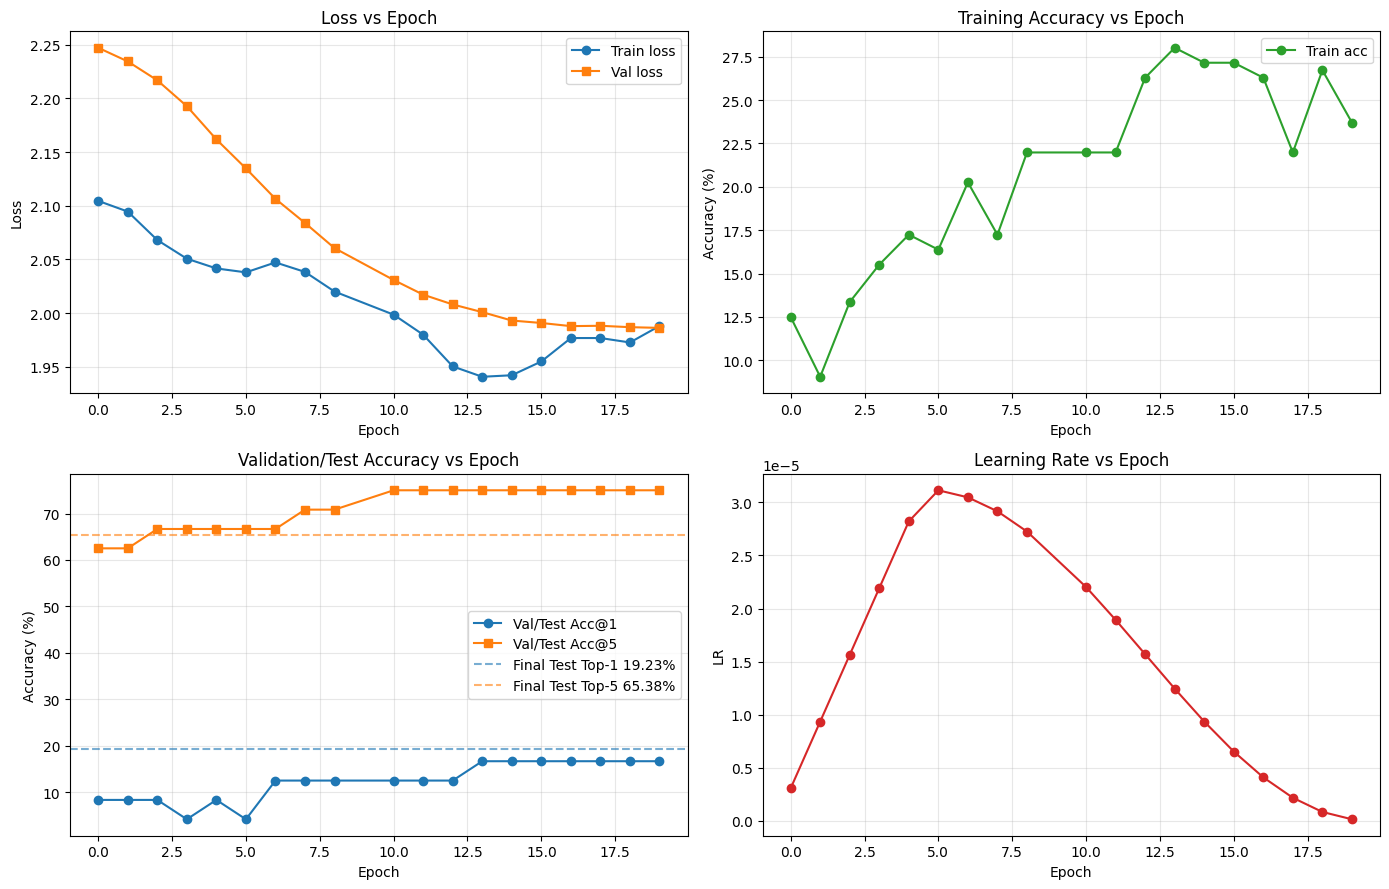

In [74]:
# Convert metric rows to arrays
epochs = np.array([r['epoch'] for r in epoch_rows])
train_loss = np.array([r.get('train_loss', np.nan) for r in epoch_rows])
train_acc = np.array([100.0 * r.get('train_class_acc', np.nan) for r in epoch_rows])
val_loss = np.array([r.get('val_loss', np.nan) for r in epoch_rows])
val_acc1 = np.array([r.get('val_acc1', np.nan) for r in epoch_rows])
val_acc5 = np.array([r.get('val_acc5', np.nan) for r in epoch_rows])
lr = np.array([r.get('train_lr', np.nan) for r in epoch_rows])

final_top1 = final_rows[-1].get('Final top-1') if final_rows else None
final_top5 = final_rows[-1].get('Final Top-5') if final_rows else None

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].plot(epochs, train_loss, marker='o', label='Train loss')
axes[0, 0].plot(epochs, val_loss, marker='s', label='Val loss')
axes[0, 0].set_title('Loss vs Epoch')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

axes[0, 1].plot(epochs, train_acc, marker='o', color='tab:green', label='Train acc')
axes[0, 1].set_title('Training Accuracy vs Epoch')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

axes[1, 0].plot(epochs, val_acc1, marker='o', label='Val/Test Acc@1')
axes[1, 0].plot(epochs, val_acc5, marker='s', label='Val/Test Acc@5')
if final_top1 is not None:
    axes[1, 0].axhline(final_top1, linestyle='--', color='tab:blue', alpha=0.6, label=f'Final Test Top-1 {final_top1:.2f}%')
if final_top5 is not None:
    axes[1, 0].axhline(final_top5, linestyle='--', color='tab:orange', alpha=0.6, label=f'Final Test Top-5 {final_top5:.2f}%')
axes[1, 0].set_title('Validation/Test Accuracy vs Epoch')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy (%)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

axes[1, 1].plot(epochs, lr, marker='o', color='tab:red')
axes[1, 1].set_title('Learning Rate vs Epoch')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('LR')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [75]:
# Parse prediction logits, average all clip/crop views per video, and compute confusion matrix
def softmax_np(x):
    x = np.asarray(x, dtype=np.float32)
    x = x - np.max(x)
    e = np.exp(x)
    return e / np.sum(e)

scores_by_video = {}
labels_by_video = {}
with pred_file.open() as f:
    lines = f.readlines()[1:]

for line in lines:
    line = line.strip()
    if not line:
        continue
    name = line.split('[', 1)[0].strip()
    score_text = '[' + line.split('[', 1)[1].split(']', 1)[0] + ']'
    rest = line.split(']', 1)[1].strip().split()
    true_label = int(rest[0])
    logits = ast.literal_eval(score_text)
    scores_by_video.setdefault(name, []).append(softmax_np(logits))
    labels_by_video[name] = true_label

video_ids = sorted(scores_by_video.keys())
y_true = []
y_pred = []
confidences = []
for vid in video_ids:
    avg_score = np.mean(scores_by_video[vid], axis=0)
    pred = int(np.argmax(avg_score))
    y_true.append(labels_by_video[vid])
    y_pred.append(pred)
    confidences.append(float(avg_score[pred]))

y_true = np.array(y_true, dtype=int)
y_pred = np.array(y_pred, dtype=int)
num_classes = len(CLASS_NAMES)
cm = np.zeros((num_classes, num_classes), dtype=int)
for t, p_ in zip(y_true, y_pred):
    cm[t, p_] += 1

overall_acc = 100.0 * np.mean(y_true == y_pred) if len(y_true) else np.nan
per_class_acc = np.divide(np.diag(cm), cm.sum(axis=1), out=np.zeros(num_classes, dtype=float), where=cm.sum(axis=1) != 0) * 100

print(f'Videos evaluated: {len(video_ids)}')
print(f'Overall accuracy: {overall_acc:.2f}%')
for i, name in enumerate(CLASS_NAMES):
    print(f'{i}: {name:12s} acc={per_class_acc[i]:6.2f}%  support={cm[i].sum()}')

Videos evaluated: 26
Overall accuracy: 19.23%
0: 1. Dog       acc=  0.00%  support=3
1: 2. Cat       acc=  0.00%  support=5
2: 3. Fish      acc=  0.00%  support=5
3: 4. Bird      acc=100.00%  support=3
4: 5. Cow       acc=  0.00%  support=0
5: 6. Mouse     acc= 66.67%  support=3
6: 7. Horse     acc=  0.00%  support=3
7: 8. Animal    acc=  0.00%  support=4


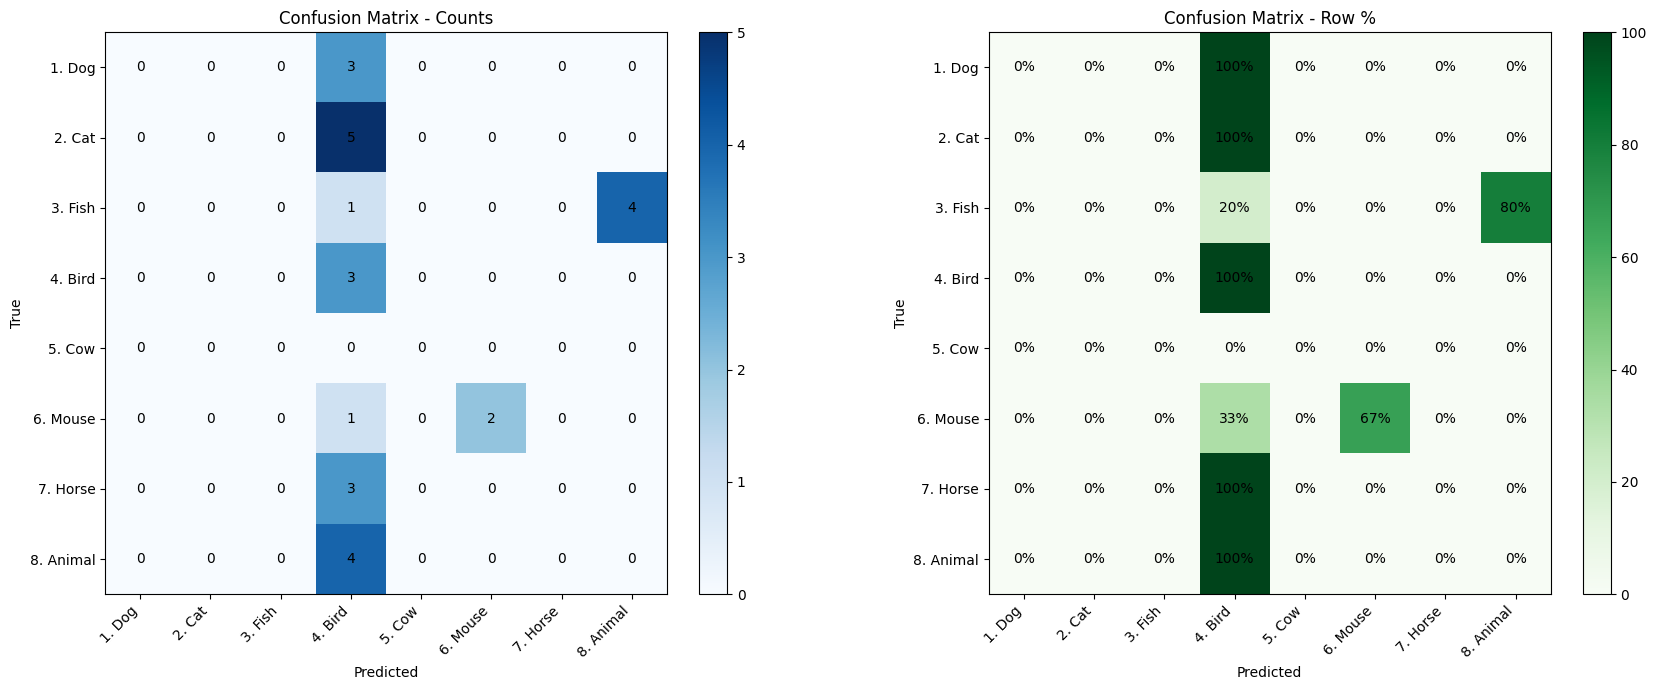

In [76]:
# Confusion matrix plots: raw counts and row-normalized percentages
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

im0 = axes[0].imshow(cm, cmap='Blues')
axes[0].set_title('Confusion Matrix - Counts')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_xticks(range(num_classes), CLASS_NAMES, rotation=45, ha='right')
axes[0].set_yticks(range(num_classes), CLASS_NAMES)
for i in range(num_classes):
    for j in range(num_classes):
        axes[0].text(j, i, str(cm[i, j]), ha='center', va='center', color='black')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

row_sums = cm.sum(axis=1, keepdims=True)
cm_pct = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0) * 100
im1 = axes[1].imshow(cm_pct, cmap='Greens', vmin=0, vmax=100)
axes[1].set_title('Confusion Matrix - Row %')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].set_xticks(range(num_classes), CLASS_NAMES, rotation=45, ha='right')
axes[1].set_yticks(range(num_classes), CLASS_NAMES)
for i in range(num_classes):
    for j in range(num_classes):
        axes[1].text(j, i, f'{cm_pct[i, j]:.0f}%', ha='center', va='center', color='black')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [77]:
# Show incorrect predictions for error analysis
mistakes = []
for vid, t, p_, conf in zip(video_ids, y_true, y_pred, confidences):
    if t != p_:
        mistakes.append((vid, CLASS_NAMES[t], CLASS_NAMES[p_], conf))

print(f'Mistakes: {len(mistakes)} / {len(video_ids)}')
for vid, true_name, pred_name, conf in mistakes[:50]:
    print(f'{vid:20s} true={true_name:12s} pred={pred_name:12s} confidence={conf:.4f}')

Mistakes: 21 / 26
MVI_2983             true=2. Cat       pred=4. Bird      confidence=0.1971
MVI_3005             true=2. Cat       pred=4. Bird      confidence=0.2650
MVI_3021             true=7. Horse     pred=4. Bird      confidence=0.2205
MVI_3027             true=8. Animal    pred=4. Bird      confidence=0.2289
MVI_3028             true=1. Dog       pred=4. Bird      confidence=0.2241
MVI_3029             true=1. Dog       pred=4. Bird      confidence=0.1741
MVI_3030             true=1. Dog       pred=4. Bird      confidence=0.1871
MVI_3031             true=2. Cat       pred=4. Bird      confidence=0.2414
MVI_3033             true=2. Cat       pred=4. Bird      confidence=0.2481
MVI_3052             true=6. Mouse     pred=4. Bird      confidence=0.2675
MVI_3068             true=3. Fish      pred=4. Bird      confidence=0.1847
MVI_3084             true=8. Animal    pred=4. Bird      confidence=0.2013
MVI_3104             true=7. Horse     pred=4. Bird      confidence=0.2114
MVI_414